# 02 - Weather Data Integration

## Objective
Fetch historical + forward weather data for the 5 active Club Piscine store cities.


## Data Sources
- **Open-Meteo Archive API** — historical daily weather (free, no key)
- **Open-Meteo Forecast API** — up to 16 days ahead (free, no key)
- **python-holidays** — Quebec + Ontario statutory holidays

## Input
- `data/processed/weekly_units.csv`

## Output
- `data/processed/weather_by_city_week.csv`
- `data/processed/weekly_units_weather.csv`
---

---
## Cell 1: Imports and Setup
---

In [1]:
import os
import json
import time 
import pandas as pd
import numpy as np
import requests
import holidays as holidays_lib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

from azure.storage.blob import BlobServiceClient
from azure.core.exceptions import ResourceNotFoundError

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette('husl')

PROJECT_ROOT   = Path('..')
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES        = PROJECT_ROOT / 'reports' / 'figures'
print('✅ Imports complete')

✅ Imports complete


---
## Cell 2: City Configuration
---

In [2]:
print(DATA_PROCESSED / 'weekly_units.csv')
weekly = pd.read_csv(DATA_PROCESSED / 'weekly_units.csv')
weekly['week_ending'] = pd.to_datetime(weekly['week_ending'])
print(f'weekly_units loaded: {weekly.shape}  (stores: {weekly["store_code"].nunique()}, divs: {weekly["division_code"].nunique()})')

# ── City coordinates for 27 active stores ──────────────────────────────────────
# CP77/CP100 sales were regrouped into CP07/CP10 in NB01 — no separate entries needed
# Excluded: CP01, CP03, CP11, CP20, CP21, CP23, CP29, CP31, CP41, CP43, CP49
CITY_COORDS = {
    'Blainville':              {'lat': 45.6700, 'lon': -73.8700, 'province': 'QC', 'store': 'CP02'},
    'Drummondville':           {'lat': 45.8833, 'lon': -72.4833, 'province': 'QC', 'store': 'CP04'},
    'Sherbrooke':              {'lat': 45.4042, 'lon': -71.8929, 'province': 'QC', 'store': 'CP05'},
    'Granby':                  {'lat': 45.4000, 'lon': -72.7333, 'province': 'QC', 'store': 'CP06'},
    'Laval':                   {'lat': 45.5833, 'lon': -73.7500, 'province': 'QC', 'store': 'CP07'},
    'Longueuil':               {'lat': 45.5317, 'lon': -73.5180, 'province': 'QC', 'store': 'CP08'},
    'Saint-Jérôme':            {'lat': 45.7833, 'lon': -74.0000, 'province': 'QC', 'store': 'CP10'},
    'St-Georges-de-Beauce':    {'lat': 46.1167, 'lon': -70.6667, 'province': 'QC', 'store': 'CP12'},
    'Victoriaville':           {'lat': 46.0500, 'lon': -71.9667, 'province': 'QC', 'store': 'CP13'},
    'Repentigny':              {'lat': 45.7333, 'lon': -73.4500, 'province': 'QC', 'store': 'CP15'},
    'Chicoutimi':              {'lat': 48.4167, 'lon': -71.0667, 'province': 'QC', 'store': 'CP16'},
    'Trois-Rivières':          {'lat': 46.3500, 'lon': -72.5500, 'province': 'QC', 'store': 'CP17'},
    "Val-d'Or":                {'lat': 48.1000, 'lon': -77.7833, 'province': 'QC', 'store': 'CP18'},
    'Nepean':                  {'lat': 45.3192, 'lon': -75.7166, 'province': 'ON', 'store': 'CP202'},
    'Pointe-aux-Trembles':     {'lat': 45.6667, 'lon': -73.5000, 'province': 'QC', 'store': 'CP28'},
    'St-Hyacinthe':            {'lat': 45.6167, 'lon': -72.9500, 'province': 'QC', 'store': 'CP32'},
    'Sorel-Tracy':             {'lat': 46.0333, 'lon': -73.1167, 'province': 'QC', 'store': 'CP33'},
    'Saint-Jean-sur-Richelieu':{'lat': 45.3000, 'lon': -73.2667, 'province': 'QC', 'store': 'CP35'},
    'Saint-Eustache':          {'lat': 45.5667, 'lon': -73.9000, 'province': 'QC', 'store': 'CP36'},
    'Gatineau':                {'lat': 45.4765, 'lon': -75.7013, 'province': 'QC', 'store': 'CP37'},
    'Joliette':                {'lat': 46.0167, 'lon': -73.4500, 'province': 'QC', 'store': 'CP39'},
    'Thetford Mines':          {'lat': 46.1000, 'lon': -71.3000, 'province': 'QC', 'store': 'CP40'},
    'St-Constant':             {'lat': 45.3688, 'lon': -73.5698, 'province': 'QC', 'store': 'CP44'},
    'Cowansville':             {'lat': 45.2000, 'lon': -72.7500, 'province': 'QC', 'store': 'CP45'},
    'Sainte-Agathe-des-Monts': {'lat': 46.0500, 'lon': -74.2833, 'province': 'QC', 'store': 'CP46'},
    'Riviere-du-Loup':         {'lat': 47.8333, 'lon': -69.5333, 'province': 'QC', 'store': 'CP47'},
    'Beloeil':                 {'lat': 45.5638, 'lon': -73.2052, 'province': 'QC', 'store': 'CP48'},
}
from datetime import date, timedelta

START_DATE = weekly['week_ending'].min().strftime('%Y-%m-%d')

# Archive API only covers up to ~5 days ago — cap END_DATE at yesterday
# Anything more recent comes from the forecast API (Cell 5)
yesterday  = date.today() - timedelta(days=1)
data_end   = weekly['week_ending'].max().date()
END_DATE   = min(data_end, yesterday).strftime('%Y-%m-%d')

FORECAST_DAYS = 16  # forward forecast from today

print(f'Date range      : {START_DATE} → {END_DATE}')
print(f'Forward forecast: {FORECAST_DAYS} days')
print(f'Cities          : {len(CITY_COORDS)}')

..\data\processed\weekly_units.csv
weekly_units loaded: (23749, 11)  (stores: 27, divs: 11)
Date range      : 2023-11-05 → 2026-03-22
Forward forecast: 16 days
Cities          : 27


---
## Cell 2.1: Validate and standardise weekly schema for merge
---

In [3]:
print("Columns in weekly_units:")
print(list(weekly.columns))

# weekly_units.csv from nb01 already has store_code, city, division_code, units, revenue
# This cell is a safety net in case any are missing
rename_map = {}
if 'No. magasin' in weekly.columns:
    rename_map['No. magasin'] = 'store_code'
weekly = weekly.rename(columns=rename_map)

# Store → city mapping for 27 active stores
# CP77/CP100 were regrouped into CP07/CP10 in NB01
STORE_TO_CITY = {
    'CP02':'Blainville',       'CP04':'Drummondville',    'CP05':'Sherbrooke',
    'CP06':'Granby',           'CP07':'Laval',            'CP08':'Longueuil',
    'CP10':'Saint-Jérôme',     'CP12':'St-Georges-de-Beauce', 'CP13':'Victoriaville',
    'CP15':'Repentigny',       'CP16':'Chicoutimi',       'CP17':'Trois-Rivières',
    'CP18':"Val-d'Or",         'CP202':'Nepean',          'CP28':'Pointe-aux-Trembles',
    'CP32':'St-Hyacinthe',     'CP33':'Sorel-Tracy',
    'CP35':'Saint-Jean-sur-Richelieu', 'CP36':'Saint-Eustache',
    'CP37':'Gatineau',         'CP39':'Joliette',         'CP40':'Thetford Mines',
    'CP44':'St-Constant',      'CP45':'Cowansville',
    'CP46':'Sainte-Agathe-des-Monts',  'CP47':'Riviere-du-Loup',
    'CP48':'Beloeil',
}

if 'city' not in weekly.columns:
    weekly['city'] = weekly['store_code'].map(STORE_TO_CITY)

missing_city = weekly['city'].isna().sum()
if missing_city:
    print(f"⚠ {missing_city} rows have no city — check STORE_TO_CITY mapping")

print(f"✅ weekly ready: {weekly.shape}")
print(f"   Columns: {list(weekly.columns)}")
weekly[['store_code','city','week_ending']].drop_duplicates().head()

Columns in weekly_units:
['week_ending', 'store_code', 'city', 'division_code', 'units', 'revenue', 'n_transactions', 'revenue_clean', 'is_return', 'is_active_product', 'weeks_with_sales']
✅ weekly ready: (23749, 11)
   Columns: ['week_ending', 'store_code', 'city', 'division_code', 'units', 'revenue', 'n_transactions', 'revenue_clean', 'is_return', 'is_active_product', 'weeks_with_sales']


,store_code,city,week_ending
0,CP02,Blainville,2023-11-05
5,CP04,Drummondville,2023-11-05
11,CP06,Granby,2023-11-05
16,CP07,Laval,2023-11-05
25,CP08,Longueuil,2023-11-05


In [4]:
# # Change to use Azure weather instead of API
# weather_weekly = pd.read_csv(DATA_PROCESSED / 'weather_by_city_week.csv')

# weather_weekly['week'] = pd.to_datetime(weather_weekly['week'])

# print("✅ Loaded Azure weather data:", weather_weekly.shape)
# weather_weekly.head()

In [5]:
# # 临时把 montreal 映射到一个 active city，先跑通 UC4
# weather_weekly['city'] = weather_weekly['city'].replace({
#     'montreal': 'Laval'
# })

---
## Cell 2.2: Connect to Azure container
---

In [6]:
# Cell A - Connect to Azure
from azure.storage.blob import BlobServiceClient
from azure.core.exceptions import ResourceNotFoundError
from io import StringIO
import pandas as pd
import json
import re
import os 

conn_str = os.getenv("AZURE_STORAGE_CONNECTION_STRING")
if not conn_str:
    raise ValueError("AZURE_STORAGE_CONNECTION_STRING is not set")
container_name = "bronze"

service = BlobServiceClient.from_connection_string(conn_str)
container = service.get_container_client(container_name)

processed_blob_name = "weather/processed/weather_daily.csv"

print("Azure Blob connection ready")

Azure Blob connection ready


In [7]:
# Cell B - Read existing weather_daily.csv
weather_daily = pd.DataFrame()

try:
    raw = container.get_blob_client(processed_blob_name).download_blob().readall()
    weather_daily = pd.read_csv(StringIO(raw.decode("utf-8")))
    weather_daily["date"] = pd.to_datetime(weather_daily["date"])
    print("Loaded processed weather_daily from Azure:", weather_daily.shape)
    print("Date range:", weather_daily["date"].min(), "->", weather_daily["date"].max())
except ResourceNotFoundError:
    print("Processed weather_daily.csv not found in Azure. Starting with empty weather table.")
except Exception as e:
    print("Failed to load processed weather_daily.csv:", e)
    print("Starting with empty weather table.")

Loaded processed weather_daily from Azure: (2974, 12)
Date range: 2025-01-01 00:00:00 -> 2026-04-02 00:00:00


In [8]:
# Cell C - Align slug
def slugify_city(city: str) -> str:
    s = unicodedata.normalize("NFKD", city)
    s = s.encode("ascii", "ignore").decode("ascii")
    s = s.lower()
    s = re.sub(r"[^a-z0-9]+", "-", s)
    s = re.sub(r"-+", "-", s).strip("-")
    return s

In [9]:
# Cell D - Amend new weather data from Azure bronze
def load_new_daily_from_raw(city, dt):
    city_slug = slugify_city(city)
    date_str = dt.strftime("%Y-%m-%d")
    blob_name = f"weather/open-meteo/{city_slug}/{date_str}.json"

    try:
        raw = container.get_blob_client(blob_name).download_blob().readall()
        data = json.loads(raw.decode("utf-8"))
    except ResourceNotFoundError:
        return None
    except Exception as e:
        print(f"Failed reading {blob_name}: {e}")
        return None

    hourly = data.get("hourly", {})
    times = hourly.get("time", [])
    if not times:
        return None

    n = len(times)

    hourly_df = pd.DataFrame({
        "time": pd.to_datetime(times),
        "temp_mean": hourly.get("temperature_2m", [None] * n),
        "precipitation": hourly.get("precipitation", [0] * n),
        "rain_sum": hourly.get("rain", [0] * n),
        "snowfall_sum": hourly.get("snowfall", [0] * n),
        "max_windspeed": hourly.get("windspeed_10m", [0] * n),
    })

    hourly_df["city"] = city
    hourly_df["date"] = hourly_df["time"].dt.floor("D")

    daily_df = (
        hourly_df.groupby(["city", "date"], as_index=False)
        .agg(
            temp_mean=("temp_mean", "mean"),
            temp_max=("temp_mean", "max"),
            precipitation=("precipitation", "sum"),
            rain_sum=("rain_sum", "sum"),
            snowfall_sum=("snowfall_sum", "sum"),
            max_windspeed=("max_windspeed", "max"),
        )
    )

    daily_df["sunshine_hours"] = 0.0
    daily_df["is_rain"] = (daily_df["rain_sum"] > 0).astype(int)
    daily_df["is_snow"] = (daily_df["snowfall_sum"] > 0).astype(int)
    daily_df["is_bad_weather"] = (
        (daily_df["rain_sum"] > 0) |
        (daily_df["snowfall_sum"] > 0) |
        (daily_df["max_windspeed"] >= 25)
    ).astype(int)

    return daily_df

In [10]:
# Cell E Calculate missing dates and update weather_daily.csv
today_dt = pd.Timestamp.today().normalize()

if weather_daily.empty:
    refresh_start = pd.to_datetime("2025-12-01")
else:
    refresh_start = weather_daily["date"].max() + pd.Timedelta(days=1)

# job captures the day before
refresh_end = today_dt - pd.Timedelta(days=1)

print("Refresh window:", refresh_start, "->", refresh_end)

new_daily_frames = []

if refresh_start <= refresh_end:
    date_list = pd.date_range(start=refresh_start, end=refresh_end, freq="D")

    for city in CITY_COORDS.keys():
        print(f"Checking new raw weather for {city}...")

        city_frames = []
        for dt in date_list:
            df = load_new_daily_from_raw(city, dt)
            if df is not None:
                city_frames.append(df)

        if city_frames:
            city_df = pd.concat(city_frames, ignore_index=True)
            new_daily_frames.append(city_df)
            print(f"  ✓ added {len(city_df)} daily rows")
        else:
            print("  - no new rows")

    if new_daily_frames:
        new_weather_daily = pd.concat(new_daily_frames, ignore_index=True)

        weather_daily = pd.concat([weather_daily, new_weather_daily], ignore_index=True)
        weather_daily = (
            weather_daily
            .drop_duplicates(subset=["city", "date"])
            .sort_values(["city", "date"])
            .reset_index(drop=True)
        )

        csv_bytes = weather_daily.to_csv(index=False).encode("utf-8")
        container.get_blob_client(processed_blob_name).upload_blob(csv_bytes, overwrite=True)

        print("Updated processed weather_daily.csv:", weather_daily.shape)
        print("Date range:", weather_daily["date"].min(), "->", weather_daily["date"].max())
    else:
        print("No new raw weather found in Azure.")
else:
    print("weather_daily is already up to date.")

Refresh window: 2026-04-03 00:00:00 -> 2026-04-04 00:00:00
Checking new raw weather for Blainville...


NameError: name 'unicodedata' is not defined

In [ ]:
# Cell F Check weather_daily
print("weather_daily shape:", weather_daily.shape)
print("date range:", weather_daily["date"].min(), "->", weather_daily["date"].max())
print("cities:", weather_daily["city"].nunique())
weather_daily.head()

weather_daily shape: (2974, 12)
date range: 2025-01-01 00:00:00 -> 2026-04-02 00:00:00
cities: 27


,city,date,temp_mean,temp_max,precipitation,rain_sum,snowfall_sum,max_windspeed,sunshine_hours,is_rain,is_snow,is_bad_weather
0,Beloeil,2025-12-01,-4.516667,1.5,0.3,0.2,0.07,23.0,0.0,1,1,1
1,Beloeil,2025-12-02,-7.166667,-5.1,3.0,0.0,2.10,13.1,0.0,0,1,1
2,Beloeil,2025-12-03,-6.566667,-0.6,0.2,0.0,0.14,21.1,0.0,0,1,1
3,Beloeil,2025-12-04,-7.195833,-0.2,2.3,0.0,1.68,26.3,0.0,0,1,1
4,Beloeil,2025-12-05,-12.795833,-8.1,0.0,0.0,0.00,17.7,0.0,0,0,0


: 

In [ ]:
# Not running - used to pull historic data to weather csv
# import json
# import pandas as pd
# from concurrent.futures import ThreadPoolExecutor, as_completed
# from azure.core.exceptions import ResourceNotFoundError

# def load_one_daily_blob(city, dt):
#     city_slug = city.lower().replace(" ", "-")
#     date_str = dt.strftime("%Y-%m-%d")
#     blob_name = f"weather/open-meteo/{city_slug}/{date_str}.json"

#     try:
#         raw = container.get_blob_client(blob_name).download_blob().readall()
#         data = json.loads(raw.decode("utf-8"))
#     except ResourceNotFoundError:
#         return None
#     except Exception as e:
#         print(f"failed: {blob_name} -> {e}")
#         return None

#     hourly = data.get("hourly", {})
#     times = hourly.get("time", [])
#     if not times:
#         return None

#     n = len(times)

#     hourly_df = pd.DataFrame({
#         "time": pd.to_datetime(times),
#         "temp_mean": hourly.get("temperature_2m", [None] * n),
#         "precipitation": hourly.get("precipitation", [0] * n),
#         "rain_sum": hourly.get("rain", [0] * n),
#         "snowfall_sum": hourly.get("snowfall", [0] * n),
#         "windspeed_10m": hourly.get("windspeed_10m", [0] * n),
#     })

#     hourly_df["city"] = city
#     hourly_df["date"] = hourly_df["time"].dt.floor("D")

#     daily_df = (
#         hourly_df.groupby(["city", "date"], as_index=False)
#         .agg(
#             temp_mean=("temp_mean", "mean"),
#             temp_max=("temp_mean", "max"),
#             precipitation=("precipitation", "sum"),
#             rain_sum=("rain_sum", "sum"),
#             snowfall_sum=("snowfall_sum", "sum"),
#             max_windspeed=("windspeed_10m", "max"),
#         )
#     )

#     daily_df["sunshine_hours"] = 0.0
#     daily_df["is_rain"] = (daily_df["rain_sum"] > 0).astype(int)
#     daily_df["is_snow"] = (daily_df["snowfall_sum"] > 0).astype(int)
#     daily_df["is_bad_weather"] = (
#         (daily_df["rain_sum"] > 0) |
#         (daily_df["snowfall_sum"] > 0) |
#         (daily_df["max_windspeed"] >= 25)
#     ).astype(int)

#     return daily_df


# if weather_daily is None:
#     start_dt = pd.to_datetime(START_DATE)
#     end_dt = pd.to_datetime(END_DATE)
#     date_list = pd.date_range(start=start_dt, end=end_dt, freq="D")

#     jobs = [(city, dt) for city in CITY_COORDS.keys() for dt in date_list]
#     all_daily = []

#     print(f"Building processed weather_daily from raw Azure JSON...")
#     print(f"Cities: {len(CITY_COORDS)} | Dates: {len(date_list)} | Total blob jobs: {len(jobs)}")

#     with ThreadPoolExecutor(max_workers=16) as executor:
#         futures = [executor.submit(load_one_daily_blob, city, dt) for city, dt in jobs]

#         for i, future in enumerate(as_completed(futures), start=1):
#             result = future.result()
#             if result is not None:
#                 all_daily.append(result)

#             if i % 200 == 0 or i == len(futures):
#                 print(f"Progress: {i}/{len(futures)}")

#     if not all_daily:
#         raise ValueError("No weather_daily data could be built from Azure raw JSON files.")

#     weather_daily = (
#         pd.concat(all_daily, ignore_index=True)
#           .drop_duplicates(subset=["city", "date"])
#           .sort_values(["city", "date"])
#           .reset_index(drop=True)
#     )

#     csv_bytes = weather_daily.to_csv(index=False).encode("utf-8")
#     container.get_blob_client(processed_blob_name).upload_blob(csv_bytes, overwrite=True)

#     print("Built and uploaded processed weather_daily.csv:", weather_daily.shape)
# else:
#     print("Processed weather_daily already loaded; skipping rebuild.")

: 

: 

In [ ]:
# # Cell C
# print("weather_daily shape:", weather_daily.shape)
# weather_daily.head()

: 

: 

---
## Not running Cell 2.3: Sort weather data in cities
---

In [ ]:
# from collections import defaultdict

# cities = sorted({name.split("/")[2] for name in all_names if name.endswith(".json")})
# print("Cities found:", cities)
# print("Number of cities:", len(cities))

# city_dates = defaultdict(list)
# for name in all_names:
#     if name.endswith(".json"):
#         parts = name.split("/")
#         # weather/open-meteo/laval/2026-03-08.json
#         if len(parts) == 4:
#             city = parts[2]
#             date_str = parts[3].replace(".json", "")
#             city_dates[city].append(date_str)

# summary = []
# for city, dates in city_dates.items():
#     summary.append((city, min(dates), max(dates), len(dates)))

# summary = sorted(summary)
# print("\nCity date ranges:")
# for row in summary:
#     print(row)

: 

: 

---
## Cell 2.4: Convert json weather files to dataframe
---

In [ ]:
# import json
# import pandas as pd

# all_hourly = []

# start_date = weekly["week_ending"].min() - pd.Timedelta(days=7)
# end_date = weekly["week_ending"].max() + pd.Timedelta(days=16)

# date_list = pd.date_range(start=start_date, end=end_date, freq="D")

# for city in CITY_COORDS.keys():
#     city_slug = city.lower().replace(" ", "-")

#     for dt in date_list:
#         date_str = dt.strftime("%Y-%m-%d")
#         blob_name = f"weather/open-meteo/{city_slug}/{date_str}.json"

#         try:
#             raw = container.get_blob_client(blob_name).download_blob().readall()
#             data = json.loads(raw.decode("utf-8"))
#         except Exception:
#             # 没有这个文件就跳过
#             continue

#         hourly = data.get("hourly", {})
#         times = hourly.get("time", [])
#         if not times:
#             continue

#         n = len(times)

#         tmp = pd.DataFrame({
#             "time": pd.to_datetime(times),
#             "temp_mean": hourly.get("temperature_2m", [None] * n),
#             "precipitation": hourly.get("precipitation", [0] * n),
#             "rain_sum": hourly.get("rain", [0] * n),
#             "snowfall_sum": hourly.get("snowfall", [0] * n),
#             "windspeed_10m": hourly.get("windspeed_10m", [0] * n),
#         })

#         tmp["city"] = city
#         all_hourly.append(tmp)

# if not all_hourly:
#     raise ValueError("No hourly weather data was loaded from Azure Blob.")

# weather_hourly = pd.concat(all_hourly, ignore_index=True)
# print("weather_hourly shape:", weather_hourly.shape)
# weather_hourly.head()

: 

: 

---
## Cell 2.5: Construct daily weather layout
---

In [ ]:
# weather_hourly["date"] = weather_hourly["time"].dt.floor("D")

# weather_daily = (
#     weather_hourly.groupby(["city", "date"], as_index=False)
#     .agg(
#         temp_mean=("temp_mean", "mean"),
#         temp_max=("temp_mean", "max"),
#         precipitation=("precipitation", "sum"),
#         rain_sum=("rain_sum", "sum"),
#         snowfall_sum=("snowfall_sum", "sum"),
#         max_windspeed=("windspeed_10m", "max"),
#     )
# )

# weather_daily["sunshine_hours"] = 0.0  
# weather_daily["is_rain"] = (weather_daily["rain_sum"] > 0).astype(int)
# weather_daily["is_snow"] = (weather_daily["snowfall_sum"] > 0).astype(int)
# weather_daily["is_bad_weather"] = (
#     (weather_daily["rain_sum"] > 0) |
#     (weather_daily["snowfall_sum"] > 0) |
#     (weather_daily["max_windspeed"] >= 25)
# ).astype(int)

# print("weather_daily shape:", weather_daily.shape)
# weather_daily.head()

: 

: 

In [ ]:
# Align city names in Azure with CITY_COORDS in UC4
CITY_NAME_MAP = {
    "blainville": "Blainville",
    "drummondville": "Drummondville",
    "sherbrooke": "Sherbrooke",
    "granby": "Granby",
    "laval": "Laval",
    "longueuil": "Longueuil",
    "saint-jerome": "Saint-Jérôme",
    "st-georges-de-beauce": "St-Georges-de-Beauce",
    "victoriaville": "Victoriaville",
    "repentigny": "Repentigny",
    "chicoutimi": "Chicoutimi",
    "trois-rivieres": "Trois-Rivières",
    "val-dor": "Val-d'Or",
    "nepean": "Nepean",
    "pointe-aux-trembles": "Pointe-aux-Trembles",
    "st-hyacinthe": "St-Hyacinthe",
    "sorel-tracy": "Sorel-Tracy",
    "saint-jean-sur-richelieu": "Saint-Jean-sur-Richelieu",
    "saint-eustache": "Saint-Eustache",
    "gatineau": "Gatineau",
    "joliette": "Joliette",
    "thetford-mines": "Thetford Mines",
    "st-constant": "St-Constant",
    "cowansville": "Cowansville",
    "sainte-agathe-des-monts": "Sainte-Agathe-des-Monts",
    "riviere-du-loup": "Riviere-du-Loup",
    "beloeil": "Beloeil",
}
weather_daily["city"] = (
    weather_daily["city"]
    .str.strip()
    .str.lower()
    .map(CITY_NAME_MAP)
    .fillna(weather_daily["city"])
)

print(sorted(weather_daily["city"].dropna().unique()))
weather_daily.head()

['Beloeil', 'Blainville', 'Chicoutimi', 'Cowansville', 'Drummondville', 'Gatineau', 'Granby', 'Joliette', 'Laval', 'Longueuil', 'Nepean', 'Pointe-aux-Trembles', 'Repentigny', 'Riviere-du-Loup', 'Saint-Eustache', 'Saint-Jean-sur-Richelieu', 'Saint-Jérôme', 'Sainte-Agathe-des-Monts', 'Sherbrooke', 'Sorel-Tracy', 'St-Constant', 'St-Georges-de-Beauce', 'St-Hyacinthe', 'Thetford Mines', 'Trois-Rivières', "Val-d'Or", 'Victoriaville']


,city,date,temp_mean,temp_max,precipitation,rain_sum,snowfall_sum,max_windspeed,sunshine_hours,is_rain,is_snow,is_bad_weather
0,Beloeil,2025-12-01,-4.516667,1.5,0.3,0.2,0.07,23.0,0.0,1,1,1
1,Beloeil,2025-12-02,-7.166667,-5.1,3.0,0.0,2.10,13.1,0.0,0,1,1
2,Beloeil,2025-12-03,-6.566667,-0.6,0.2,0.0,0.14,21.1,0.0,0,1,1
3,Beloeil,2025-12-04,-7.195833,-0.2,2.3,0.0,1.68,26.3,0.0,0,1,1
4,Beloeil,2025-12-05,-12.795833,-8.1,0.0,0.0,0.00,17.7,0.0,0,0,0


: 

---
## Cell 2.6: Aggregate weather to cities
---

In [ ]:
city_meta = pd.DataFrame([
    {
        "city": city,
        "store_code": coords["store"],
        "province": coords["province"]
    }
    for city, coords in CITY_COORDS.items()
])

weather_daily = weather_daily.drop(columns=["store_code", "province"], errors="ignore")

weather_daily = weather_daily.merge(city_meta, on="city", how="left")

print("Columns after city merge:")
print(list(weather_daily.columns))
print("Rows with missing store_code after city mapping:", weather_daily["store_code"].isna().sum())
weather_daily.head()

Columns after city merge:
['city', 'date', 'temp_mean', 'temp_max', 'precipitation', 'rain_sum', 'snowfall_sum', 'max_windspeed', 'sunshine_hours', 'is_rain', 'is_snow', 'is_bad_weather', 'store_code', 'province']
Rows with missing store_code after city mapping: 0


,city,date,temp_mean,temp_max,precipitation,rain_sum,snowfall_sum,max_windspeed,sunshine_hours,is_rain,is_snow,is_bad_weather,store_code,province
0,Beloeil,2025-12-01,-4.516667,1.5,0.3,0.2,0.07,23.0,0.0,1,1,1,CP48,QC
1,Beloeil,2025-12-02,-7.166667,-5.1,3.0,0.0,2.10,13.1,0.0,0,1,1,CP48,QC
2,Beloeil,2025-12-03,-6.566667,-0.6,0.2,0.0,0.14,21.1,0.0,0,1,1,CP48,QC
3,Beloeil,2025-12-04,-7.195833,-0.2,2.3,0.0,1.68,26.3,0.0,0,1,1,CP48,QC
4,Beloeil,2025-12-05,-12.795833,-8.1,0.0,0.0,0.00,17.7,0.0,0,0,0,CP48,QC


: 

---
## Cell 2.7: Aggregate weekly weather
---

In [ ]:
def aggregate_weather_weekly_from_daily(df):
    return (
        df.set_index("date")
          .groupby(["store_code", "city", "province"])
          .resample("W")
          .agg(
              avg_temp=("temp_mean", "mean"),
              max_temp=("temp_max", "max"),
              total_precip=("precipitation", "sum"),
              sunshine_hours=("sunshine_hours", "sum"),
              rain_days=("is_rain", "sum"),
              snow_days=("is_snow", "sum"),
              bad_weather_days=("is_bad_weather", "sum")
          )
          .reset_index()
          .rename(columns={"date": "week_ending"})
    )

weather_weekly = aggregate_weather_weekly_from_daily(weather_daily)

num_cols = weather_weekly.select_dtypes(include=np.number).columns
weather_weekly[num_cols] = weather_weekly[num_cols].round(2)

print("weather_weekly shape:", weather_weekly.shape)
print("Date range:", weather_weekly["week_ending"].min(), "->", weather_weekly["week_ending"].max())
weather_weekly.head()

weather_weekly shape: (917, 11)
Date range: 2025-01-05 00:00:00 -> 2026-04-05 00:00:00


,store_code,city,province,week_ending,avg_temp,max_temp,total_precip,sunshine_hours,rain_days,snow_days,bad_weather_days
0,CP02,Blainville,QC,2025-01-05,-2.5,0.9,6.5,0.0,2,3,3
1,CP02,Blainville,QC,2025-01-12,NaN,NaN,0.0,0.0,0,0,0
2,CP02,Blainville,QC,2025-01-19,NaN,NaN,0.0,0.0,0,0,0
3,CP02,Blainville,QC,2025-01-26,NaN,NaN,0.0,0.0,0,0,0
4,CP02,Blainville,QC,2025-02-02,NaN,NaN,0.0,0.0,0,0,0


: 

In [ ]:
# weather_weekly.to_csv(DATA_PROCESSED / "weather_by_city_week.csv", index=False)
# print("✅ Saved weather_by_city_week.csv")

: 

: 

In [ ]:
weekly_units_weather = weekly.merge(
    weather_weekly,
    on=["store_code", "week_ending"],
    how="left"
)

weekly_units_weather = weekly_units_weather.rename(columns={
    "city_x": "city"
}).drop(columns=["city_y"], errors="ignore")

print("weekly_units_weather shape:", weekly_units_weather.shape)
weekly_units_weather.head()

weekly_units_weather shape: (23749, 19)


,week_ending,store_code,city,division_code,units,revenue,n_transactions,revenue_clean,is_return,is_active_product,weeks_with_sales,province,avg_temp,max_temp,total_precip,sunshine_hours,rain_days,snow_days,bad_weather_days
0,2023-11-05,CP02,Blainville,FI,1.0,2599.00,1,2599.00,0,1,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-11-05,CP02,Blainville,GA,3.0,1049.97,3,1049.97,0,1,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-11-05,CP02,Blainville,LO,13.0,71.87,7,71.87,0,1,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-11-05,CP02,Blainville,ME,1.0,219.99,1,219.99,0,1,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-11-05,CP02,Blainville,PC,263.0,4085.98,68,4085.98,0,1,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


: 

In [ ]:
weather_weekly.to_csv(DATA_PROCESSED / "weather_by_city_week.csv", index=False)
weekly_units_weather.to_csv(DATA_PROCESSED / "weekly_units_weather.csv", index=False)
print("✅ Saved both CSV files")

✅ Saved both CSV files


: 

In [ ]:
# #Test 
# print("weekly date range:")
# print(weekly["week_ending"].min(), weekly["week_ending"].max())

# print("weather_weekly date range:")
# print(weather_weekly["week_ending"].min(), weather_weekly["week_ending"].max())

# print("weekly stores:", weekly["store_code"].nunique())
# print("weather stores:", weather_weekly["store_code"].nunique())
# print(sorted(weather_weekly["store_code"].dropna().unique()))

# weather_cols = ["avg_temp", "max_temp", "total_precip", "sunshine_hours", "rain_days", "snow_days", "bad_weather_days"]

# matched = weekly_units_weather["avg_temp"].notna().sum()
# print("Rows with weather matched:", matched)
# print("Total rows:", len(weekly_units_weather))
# print("Match rate:", matched / len(weekly_units_weather))

# weekly_units_weather.loc[
#     weekly_units_weather["avg_temp"].notna(),
#     ["week_ending", "store_code", "city", "avg_temp", "max_temp", "total_precip"]
# ].head(20)

: 

: 

---
## Cell 3: Weather Classification (WMO Codes)
---

In [ ]:
def classify_weather(df):
    """
    Map WMO weather codes to conditions and binary flags.
    Reference: https://open-meteo.com/en/docs#weathervariables
    """
    def get_condition(code):
        if   code == 0:                return 'Clear'
        elif code in range(1, 4):      return 'Cloudy'
        elif code in range(45, 50):    return 'Fog'
        elif code in range(51, 68):    return 'Rain'
        elif code in range(71, 78):    return 'Snow'
        elif code in range(80, 83):    return 'Rain'
        elif code in range(85, 87):    return 'Snow'
        elif code in range(95, 100):   return 'Thunderstorm'
        else:                           return 'Other'

    df = df.copy()
    df['weather_condition'] = df['weathercode'].apply(get_condition)
    df['is_rain']            = (df['weather_condition'] == 'Rain').astype(int)
    df['is_snow']            = (df['weather_condition'] == 'Snow').astype(int)
    df['is_bad_weather']     = df['weather_condition'].isin(
        ['Rain', 'Snow', 'Thunderstorm', 'Fog']).astype(int)
    return df

print('✅ classify_weather() defined')

✅ classify_weather() defined


: 

---
## Cell 4: Fetch Historical Weather
---

In [ ]:
# # ❌ DISABLED: replaced by Azure weather ingestion
# import time

# def fetch_historical_weather(city, lat, lon, start_date, end_date, max_retries=4):
#     url    = 'https://archive-api.open-meteo.com/v1/archive'
#     params = {
#         'latitude': lat, 'longitude': lon,
#         'start_date': start_date, 'end_date': end_date,
#         'daily': ['temperature_2m_mean','temperature_2m_max',
#                   'precipitation_sum','weathercode','sunshine_duration'],
#         'timezone': 'America/Toronto'
#     }
#     for attempt in range(max_retries):
#         r = requests.get(url, params=params, timeout=30)
#         if r.status_code == 429:
#             wait = 2 ** (attempt + 2)   # 4s, 8s, 16s, 32s
#             print(f'      Rate limited — waiting {wait}s...')
#             time.sleep(wait)
#             continue
#         r.raise_for_status()
#         data = r.json()['daily']
#         df   = pd.DataFrame({
#             'date':           pd.to_datetime(data['time']),
#             'temp_mean':      data['temperature_2m_mean'],
#             'temp_max':       data['temperature_2m_max'],
#             'precipitation':  data['precipitation_sum'],
#             'weathercode':    [int(c) for c in data['weathercode']],
#             'sunshine_hours': [s/3600 if s else 0 for s in data['sunshine_duration']],
#             'city': city
#         }).fillna(0)
#         return classify_weather(df)
#     raise Exception(f'Failed after {max_retries} retries (rate limit)')


# all_hist = []
# for city, coords in CITY_COORDS.items():
#     print(f'  Fetching historical: {city}...')
#     try:
#         df = fetch_historical_weather(city, coords['lat'], coords['lon'], START_DATE, END_DATE)
#         all_hist.append(df)
#         print(f'    ✓ {len(df)} days')
#     except Exception as e:
#         print(f'    ✗ Failed: {e}')
#     time.sleep(2)   # 2s pause between every city to stay under rate limit

# weather_daily = pd.concat(all_hist, ignore_index=True) if all_hist else pd.DataFrame()
# n_cities_ok  = len(all_hist)
# n_cities_tot = len(CITY_COORDS)
# print(f'\n✅ Historical weather: {weather_daily.shape[0]:,} daily records across {n_cities_ok}/{n_cities_tot} cities')
# if n_cities_ok < n_cities_tot:
#     fetched = {df['city'].iloc[0] for df in all_hist}
#     missing = [c for c in CITY_COORDS if c not in fetched]
#     print(f'⚠ Missing cities: {missing} — re-run this cell to retry')


: 

: 

---
## Cell 5: Fetch Forward Forecast (16 days)
---

In [ ]:
# # DISABLED: replaced by Azure weather ingestion
# # Cell 5: Fetch forecast weather (robust to None values)

# all_fcast = []

# for city, meta in CITY_COORDS.items():
#     lat = meta["lat"]
#     lon = meta["lon"]

#     print(f"Fetching forecast: {city}...")

#     url = "https://api.open-meteo.com/v1/forecast"
#     params = {
#         "latitude": lat,
#         "longitude": lon,
#         "daily": "temperature_2m_mean,temperature_2m_max,precipitation_sum,sunshine_duration,rain_sum,snowfall_sum",
#         "forecast_days": 16,
#         "timezone": "auto"
#     }

#     try:
#         response = requests.get(url, params=params, timeout=30)
#         response.raise_for_status()
#         data = response.json()

#         if "daily" not in data:
#             print(f"    ✗ Failed: no 'daily' field returned")
#             print(data)
#             continue

#         daily = data["daily"]

#         df = pd.DataFrame({
#             "date": pd.to_datetime(daily.get("time", [])),
#             "temp_mean": daily.get("temperature_2m_mean", []),
#             "temp_max": daily.get("temperature_2m_max", []),
#             "precipitation": daily.get("precipitation_sum", []),
#             "sunshine_duration": daily.get("sunshine_duration", []),
#             "rain_sum": daily.get("rain_sum", []),
#             "snowfall_sum": daily.get("snowfall_sum", []),
#         })

#         # attach city
#         df["city"] = city

#         # convert numeric columns safely
#         num_cols = [
#             "temp_mean",
#             "temp_max",
#             "precipitation",
#             "sunshine_duration",
#             "rain_sum",
#             "snowfall_sum",
#         ]

#         for col in num_cols:
#             df[col] = pd.to_numeric(df[col], errors="coerce")

#         # fill missing weather values with 0 where appropriate
#         df["precipitation"] = df["precipitation"].fillna(0)
#         df["sunshine_duration"] = df["sunshine_duration"].fillna(0)
#         df["rain_sum"] = df["rain_sum"].fillna(0)
#         df["snowfall_sum"] = df["snowfall_sum"].fillna(0)

#         # convert sunshine duration seconds -> hours
#         df["sunshine_hours"] = df["sunshine_duration"] / 3600.0

#         # binary indicators
#         df["is_rain"] = (df["rain_sum"] > 0).astype(int)
#         df["is_snow"] = (df["snowfall_sum"] > 0).astype(int)
#         df["is_bad_weather"] = ((df["rain_sum"] > 0) | (df["snowfall_sum"] > 0)).astype(int)

#         # keep only columns needed downstream
#         df = df[
#             [
#                 "date",
#                 "temp_mean",
#                 "temp_max",
#                 "precipitation",
#                 "sunshine_hours",
#                 "rain_sum",
#                 "snowfall_sum",
#                 "city",
#                 "is_rain",
#                 "is_snow",
#                 "is_bad_weather",
#             ]
#         ]

#         all_fcast.append(df)
#         print(f"    ✓ Success: {len(df)} rows")

#     except Exception as e:
#         print(f"    ✗ Failed: {e}")

# if len(all_fcast) == 0:
#     weather_fcast_daily = pd.DataFrame(
#         columns=[
#             "date",
#             "temp_mean",
#             "temp_max",
#             "precipitation",
#             "sunshine_hours",
#             "rain_sum",
#             "snowfall_sum",
#             "city",
#             "is_rain",
#             "is_snow",
#             "is_bad_weather",
#         ]
#     )
#     print("\n⚠ No forecast weather data retrieved.")
# else:
#     weather_fcast_daily = pd.concat(all_fcast, ignore_index=True)
#     print(f"\nForecast weather: {weather_fcast_daily.shape[0]:,} daily records")

# weather_fcast_daily.head()

: 

: 

---
## New Cell 6: Adapt Azure weather_weekly schema to match downstream notebook
---

In [ ]:
# Cell 6: Adapt Azure weather_weekly schema to match downstream notebook

city_meta = pd.DataFrame([
    {
        'city': city,
        'store_code': coords['store'],
        'province': coords['province']
    }
    for city, coords in CITY_COORDS.items()
])

# unify city format
city_meta['city_key'] = city_meta['city'].str.strip().str.lower()
weather_weekly['city_key'] = weather_weekly['city'].str.strip().str.lower()

# change Azure CSV's week to downstream's week_ending
weather_weekly = weather_weekly.rename(columns={'week': 'week_ending'})

weather_weekly = weather_weekly.drop(
    columns=['store_code', 'province'],
    errors='ignore'
)

weather_weekly = weather_weekly.merge(
    city_meta[['city_key', 'store_code', 'province']],
    on='city_key',
    how='left'
)

# add the columns that downstream needs
for col in ['sunshine_hours', 'rain_days', 'snow_days', 'bad_weather_days']:
    if col not in weather_weekly.columns:
        weather_weekly[col] = 0

weather_weekly = weather_weekly.drop(columns=['city_key'])

weather_weekly = weather_weekly[
    [
        'store_code',
        'city',
        'province',
        'week_ending',
        'avg_temp',
        'max_temp',
        'total_precip',
        'sunshine_hours',
        'rain_days',
        'snow_days',
        'bad_weather_days',
    ]
]

num_cols = weather_weekly.select_dtypes(include=np.number).columns
weather_weekly[num_cols] = weather_weekly[num_cols].round(2)

print("Columns after merge:")
print(list(weather_weekly.columns))
print()
print(f"Weekly weather: {weather_weekly.shape}")
print(f"Date range: {weather_weekly['week_ending'].min().date()} → {weather_weekly['week_ending'].max().date()}")
weather_weekly.head()

Columns after merge:
['store_code', 'city', 'province', 'week_ending', 'avg_temp', 'max_temp', 'total_precip', 'sunshine_hours', 'rain_days', 'snow_days', 'bad_weather_days']

Weekly weather: (917, 11)
Date range: 2025-01-05 → 2026-04-05


,store_code,city,province,week_ending,avg_temp,max_temp,total_precip,sunshine_hours,rain_days,snow_days,bad_weather_days
0,CP02,Blainville,QC,2025-01-05,-2.5,0.9,6.5,0.0,2,3,3
1,CP02,Blainville,QC,2025-01-12,NaN,NaN,0.0,0.0,0,0,0
2,CP02,Blainville,QC,2025-01-19,NaN,NaN,0.0,0.0,0,0,0
3,CP02,Blainville,QC,2025-01-26,NaN,NaN,0.0,0.0,0,0,0
4,CP02,Blainville,QC,2025-02-02,NaN,NaN,0.0,0.0,0,0,0


: 

In [ ]:
weather_weekly.to_csv(DATA_PROCESSED / 'weather_by_city_week.csv', index=False)
print("✅ Saved adapted weather_by_city_week.csv")

✅ Saved adapted weather_by_city_week.csv


: 

In [ ]:
#pd.read_csv(DATA_PROCESSED / 'weather_by_city_week.csv').head()

: 

: 

In [ ]:
# merge units + weather

weekly_units_weather = weekly.merge(
    weather_weekly,
    on=['store_code', 'week_ending'],
    how='left'
)

print("Merged dataset:", weekly_units_weather.shape)
weekly_units_weather.head()

Merged dataset: (23749, 20)


,week_ending,store_code,city_x,division_code,units,revenue,n_transactions,revenue_clean,is_return,is_active_product,weeks_with_sales,city_y,province,avg_temp,max_temp,total_precip,sunshine_hours,rain_days,snow_days,bad_weather_days
0,2023-11-05,CP02,Blainville,FI,1.0,2599.00,1,2599.00,0,1,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-11-05,CP02,Blainville,GA,3.0,1049.97,3,1049.97,0,1,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-11-05,CP02,Blainville,LO,13.0,71.87,7,71.87,0,1,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-11-05,CP02,Blainville,ME,1.0,219.99,1,219.99,0,1,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-11-05,CP02,Blainville,PC,263.0,4085.98,68,4085.98,0,1,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


: 

In [ ]:
weekly_units_weather = weekly_units_weather.rename(columns={
    'city_x': 'city'
}).drop(columns=['city_y'], errors='ignore')

weekly_units_weather.head()

,week_ending,store_code,city,division_code,units,revenue,n_transactions,revenue_clean,is_return,is_active_product,weeks_with_sales,province,avg_temp,max_temp,total_precip,sunshine_hours,rain_days,snow_days,bad_weather_days
0,2023-11-05,CP02,Blainville,FI,1.0,2599.00,1,2599.00,0,1,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-11-05,CP02,Blainville,GA,3.0,1049.97,3,1049.97,0,1,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-11-05,CP02,Blainville,LO,13.0,71.87,7,71.87,0,1,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-11-05,CP02,Blainville,ME,1.0,219.99,1,219.99,0,1,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-11-05,CP02,Blainville,PC,263.0,4085.98,68,4085.98,0,1,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


: 

In [ ]:
weekly_units_weather.to_csv(DATA_PROCESSED / 'weekly_units_weather.csv', index=False)

: 

---
## Cell 6: Aggregate to Weekly
---

In [ ]:
# # ❌ DISABLED: replaced by Azure weather ingestion
# # Cell 6: Aggregate daily weather to weekly weather with store/city/province retained

# def aggregate_weather_weekly(df):
#     return (
#         df.set_index('date')
#           .groupby(['store_code', 'city', 'province'])
#           .resample('W')
#           .agg(
#               avg_temp=('temp_mean', 'mean'),
#               max_temp=('temp_max', 'max'),
#               total_precip=('precipitation', 'sum'),
#               sunshine_hours=('sunshine_hours', 'sum'),
#               rain_days=('is_rain', 'sum'),
#               snow_days=('is_snow', 'sum'),
#               bad_weather_days=('is_bad_weather', 'sum')
#           )
#           .reset_index()
#           .rename(columns={'date': 'week_ending'})
#     )

# city_meta = pd.DataFrame([
#     {
#         'city': city,
#         'store_code': coords['store'],
#         'province': coords['province']
#     }
#     for city, coords in CITY_COORDS.items()
# ])

# weather_daily = weather_daily.merge(city_meta, on='city', how='left')
# weather_fcast_daily = weather_fcast_daily.merge(city_meta, on='city', how='left')

# hist_weekly = aggregate_weather_weekly(weather_daily)
# fcast_weekly = aggregate_weather_weekly(weather_fcast_daily)

# weather_weekly = (
#     pd.concat([hist_weekly, fcast_weekly], ignore_index=True)
#       .drop_duplicates(subset=['store_code', 'city', 'week_ending'])
#       .sort_values(['store_code', 'week_ending'])
#       .reset_index(drop=True)
# )

# num_cols = weather_weekly.select_dtypes(include=np.number).columns
# weather_weekly[num_cols] = weather_weekly[num_cols].round(2)

# print(f"Weekly weather: {weather_weekly.shape}")
# print(f"Date range: {weather_weekly['week_ending'].min().date()} → {weather_weekly['week_ending'].max().date()}")
# weather_weekly.head()

: 

: 

In [ ]:
# print("weekly columns:")
# print(list(weekly.columns))

# weekly.head()

: 

: 

In [ ]:
# # Merge weekly sales with weekly weather

# merge_keys = ['week_ending', 'store_code', 'city']

# weekly_sales_weather = weekly.merge(
#     weather_weekly,
#     on=merge_keys,
#     how='left'
# )

# print("Merged dataset shape:", weekly_sales_weather.shape)
# print("Missing weather rows:", weekly_sales_weather['avg_temp'].isna().sum())

# weekly_sales_weather.head()

: 

: 

In [ ]:
# # Save outputs

# weather_weekly.to_csv(DATA_PROCESSED / 'weather_by_city_week.csv', index=False)
# weekly_sales_weather.to_csv(DATA_PROCESSED / 'weekly_units_weather.csv', index=False)

# print("Saved weather_by_city_week.csv")
# print("Saved weekly_units_weather.csv")

: 

: 

## Output Summary

This notebook produces two datasets for downstream forecasting:

1. `weather_by_city_week.csv`
2. `weekly_units_weather.csv`

These outputs will be used in `03_feature_engineering.ipynb`.

---
## Cell 7: Quebec & Ontario Holidays
---

In [ ]:
years_in_data = sorted(weekly['week_ending'].dt.year.unique().tolist())
city_province = {city: v['province'] for city, v in CITY_COORDS.items()}

hol_records = []
for prov in ['QC', 'ON']:
    for date, name in holidays_lib.Canada(prov=prov, years=years_in_data).items():
        hol_records.append({'date': pd.Timestamp(date), 'holiday': name, 'province': prov})

holidays_df = pd.DataFrame(hol_records)
holidays_df['week_ending'] = holidays_df['date'] + pd.offsets.Week(weekday=6)

city_prov_df = pd.DataFrame([{'city': c, 'province': p} for c, p in city_province.items()])
holiday_weekly = (
    holidays_df.merge(city_prov_df, on='province')
               .groupby(['city','week_ending'])
               .agg(n_holidays=('holiday','count'), has_holiday=('holiday', lambda x: 1))
               .reset_index()
)
print(f'✅ {len(holidays_df)} holiday records (QC + ON)')

✅ 70 holiday records (QC + ON)


: 

---
## Cell 8: Merge Weather + Holidays onto Sales
---

In [ ]:
weekly_weather = weekly.merge(weather_weekly, on=['city','week_ending'], how='left')
# Ensure store_code is present (may be dropped if weather_weekly also has it)
if 'store_code' not in weekly_weather.columns and 'store_code' in weekly.columns:
    weekly_weather = weekly_weather.merge(weekly[['city','week_ending','division_code','store_code']].drop_duplicates(),
                                           on=['city','week_ending','division_code'], how='left')
weekly_weather = weekly_weather.merge(
    holiday_weekly[['city','week_ending','n_holidays','has_holiday']],
    on=['city','week_ending'], how='left'
)
weekly_weather['n_holidays']  = weekly_weather['n_holidays'].fillna(0).astype(int)
weekly_weather['has_holiday'] = weekly_weather['has_holiday'].fillna(0).astype(int)

# Fill weather gaps with monthly median per city
weekly_weather['month'] = weekly_weather['week_ending'].dt.month
for col in ['avg_temp','total_precip','rain_days','snow_days','bad_weather_days','sunshine_hours']:
    if col in weekly_weather.columns:
        med = weekly_weather.groupby(['city','month'])[col].transform('median')
        weekly_weather[col] = weekly_weather[col].fillna(med)

print(f'Merged dataset: {weekly_weather.shape}')

Merged dataset: (23749, 24)


: 

---
## Cell 9: Weather vs Sales Visualizations
---

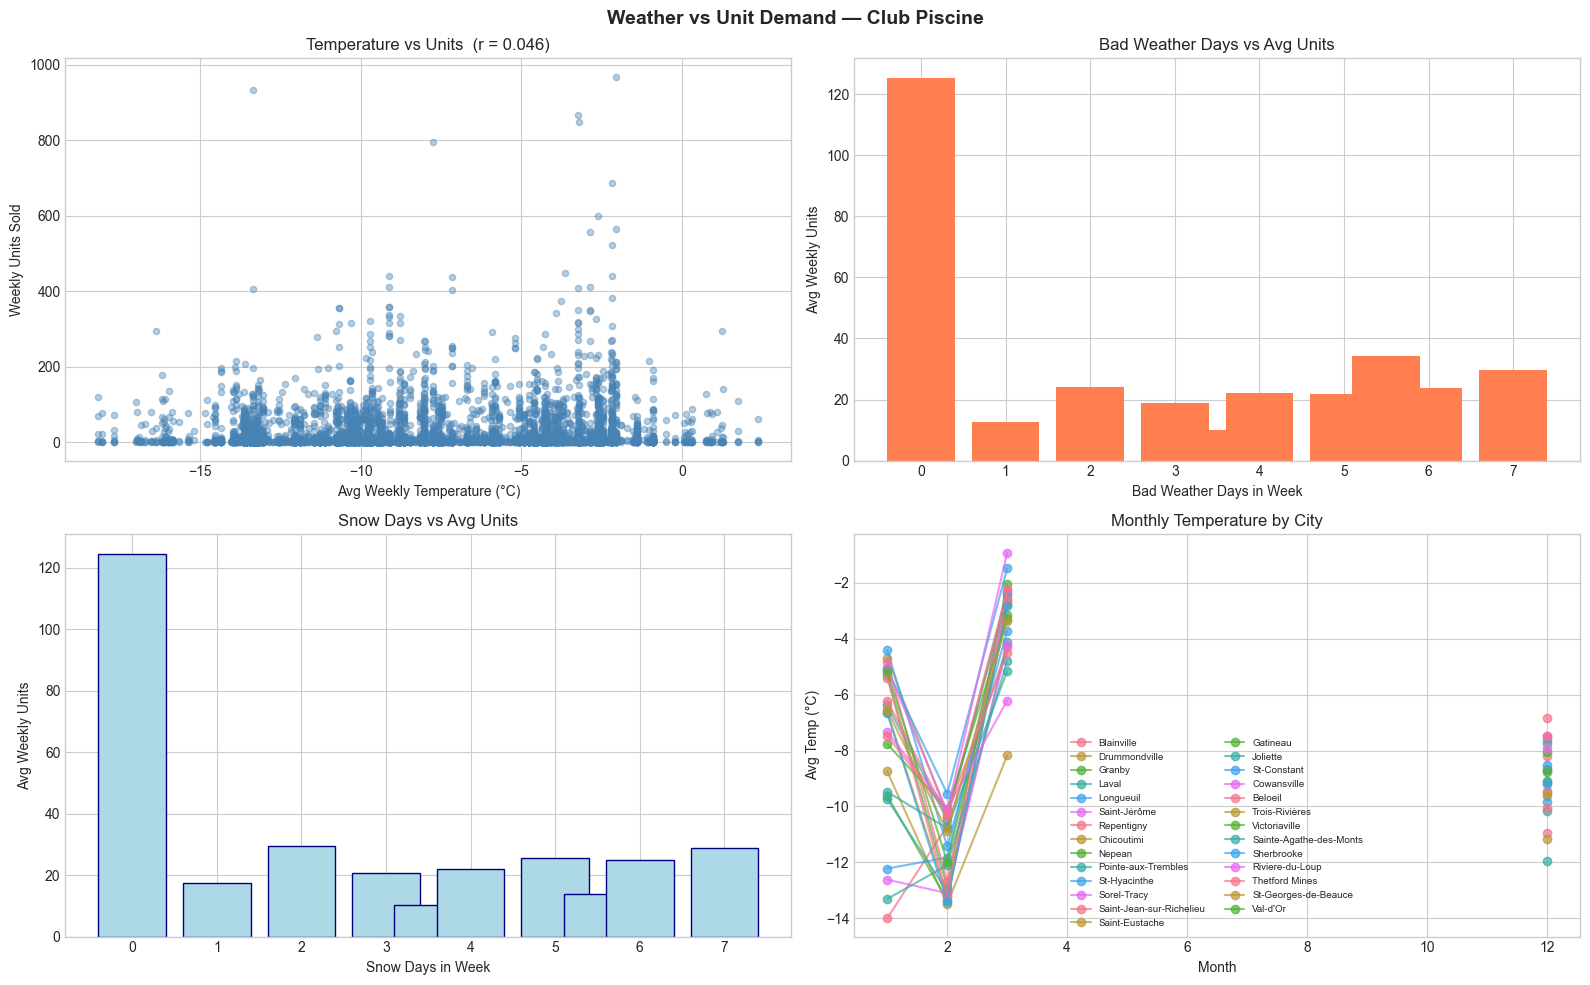

✅ Saved: weather_vs_units.png


: 

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax1 = axes[0, 0]
ax1.scatter(weekly_weather['avg_temp'], weekly_weather['units'], alpha=0.4, color='steelblue', s=20)
corr = weekly_weather['avg_temp'].corr(weekly_weather['units'])
ax1.set_xlabel('Avg Weekly Temperature (°C)')
ax1.set_ylabel('Weekly Units Sold')
ax1.set_title(f'Temperature vs Units  (r = {corr:.3f})')

ax2 = axes[0, 1]
bw = weekly_weather.groupby('bad_weather_days')['units'].mean()
ax2.bar(bw.index, bw.values, color='coral')
ax2.set_xlabel('Bad Weather Days in Week')
ax2.set_ylabel('Avg Weekly Units')
ax2.set_title('Bad Weather Days vs Avg Units')

ax3 = axes[1, 0]
sn = weekly_weather.groupby('snow_days')['units'].mean()
ax3.bar(sn.index, sn.values, color='lightblue', edgecolor='navy')
ax3.set_xlabel('Snow Days in Week')
ax3.set_ylabel('Avg Weekly Units')
ax3.set_title('Snow Days vs Avg Units')

ax4 = axes[1, 1]
for city in weekly_weather['city'].dropna().unique():
    d = weekly_weather[weekly_weather['city']==city].groupby('month')['avg_temp'].mean()
    ax4.plot(d.index, d.values, marker='o', label=city, alpha=0.7)
ax4.set_xlabel('Month')
ax4.set_ylabel('Avg Temp (°C)')
ax4.set_title('Monthly Temperature by City')
ax4.legend(fontsize=7, ncol=2)

plt.suptitle('Weather vs Unit Demand — Club Piscine', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'weather_vs_units.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: weather_vs_units.png')


---
## Cell 10: Save Outputs
---

In [ ]:
weather_weekly.to_csv(DATA_PROCESSED / 'weather_by_city_week.csv', index=False)
weekly_weather.to_csv(DATA_PROCESSED / 'weekly_units_weather.csv', index=False)
print(f'✅ Saved: weather_by_city_week.csv  ({weather_weekly.shape})')
print(f'✅ Saved: weekly_units_weather.csv  ({weekly_weather.shape})')
print('Next → 03_feature_engineering.ipynb')

✅ Saved: weather_by_city_week.csv  ((917, 11))
✅ Saved: weekly_units_weather.csv  ((23749, 24))
Next → 03_feature_engineering.ipynb


: 